Assignment 13
Name: Shlok Nikam
PRN: 12414145
Batch: 2
Division: D
Branch: CSE(AI)


13.  Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris




Read File and Clean Columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
iris = pd.read_csv("iris_plant.csv")

if "Id" in iris.columns:
    iris = iris.drop("Id", axis=1)

Manual outlier removal

In [ ]:
numeric = iris.iloc[:, :-1]

lower = numeric.quantile(0.25) - 1.5 * (numeric.quantile(0.75) - numeric.quantile(0.25))
upper = numeric.quantile(0.75) + 1.5 * (numeric.quantile(0.75) - numeric.quantile(0.25))

clean_data = iris[~((numeric < lower) | (numeric > upper)).any(axis=1)]

Extract X

In [ ]:
X = clean_data.iloc[:, :-1].values

Normalizing

In [ ]:

norm = StandardScaler()
X_norm = norm.fit_transform(X)

Elbow calculation with elbow graph

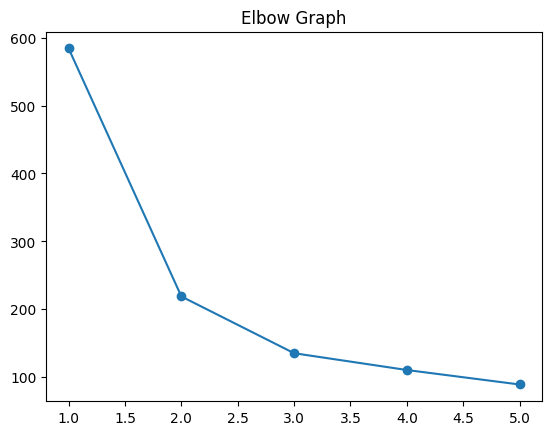

In [ ]:

wcss = []
for i in range(1, 6):
    k = KMeans(n_clusters=i, random_state=2, n_init=10)
    k.fit(X_norm)
    wcss.append(k.inertia_)

plt.plot(range(1, 6), wcss, marker='o')
plt.title("Elbow Graph")
plt.show()

Fit final model

In [ ]:

k = KMeans(n_clusters=3, random_state=2, n_init=10)
labels = k.fit_predict(X_norm)

Visualize

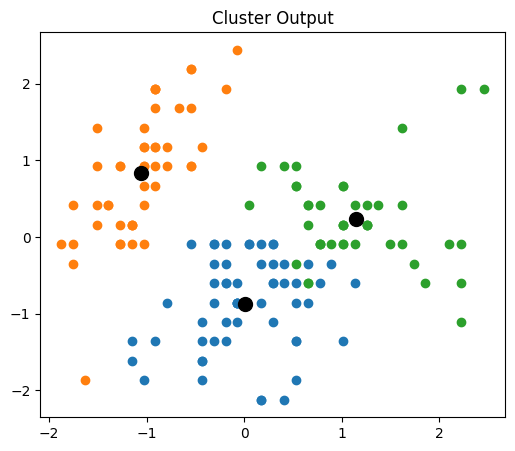

In [ ]:

plt.figure(figsize=(6,5))

for i in range(3):
    plt.scatter(X_norm[labels == i, 0],
                X_norm[labels == i, 1])

plt.scatter(k.cluster_centers_[:, 0],
            k.cluster_centers_[:, 1],
            c='black', s=100)

plt.title("Cluster Output")
plt.show()

Silhouette Score

In [ ]:
print("Silhouette Score:", silhouette_score(X_norm, labels))

Silhouette Score: 0.46634515335503746
